# Conditional β-VAE for dose-specific time courses

This notebook trains a conditional variational autoencoder on the same six-dose trajectory dataset. The encoder learns a Gaussian latent posterior; the decoder receives both a latent sample and a dose embedding. A frozen copy of the validation-winning Gated-Fusion classifier supplies a small auxiliary dose-consistency loss.

Unlike a GAN, the VAE has an explicit reconstruction objective and approximate likelihood model. It is typically easier to train and covers modes more reliably, but an element-wise Gaussian reconstruction loss can produce smoother, less sharp trajectories.

## Design

The model operates on train-normalized signals. The decoder predicts 72 coarse feature points, upsamples to all 289 time points and applies convolutional refinement. Both KL weight and classifier guidance are warmed up: KL warm-up reduces posterior collapse, while guidance warm-up prevents an initially random decoder from receiving an excessive classifier gradient. Model selection uses reconstruction-plus-KL loss on `validate`; `test` remains unopened until training is complete.

In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

from deeplearning_examples.io import load_data
from pytorch_cdgan.model import initialize_weights
from pytorch_timecourse_classification.artifacts import artifact_dir_for, load_model, load_selection_manifest

RANDOM_SEED = 41
LATENT_DIM = 24
CONDITION_DIM = 8
EPOCHS = int(os.getenv("VAE_EPOCHS", "250"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(Markdown(f"**Runtime:** `{device}` device, **{EPOCHS} epochs** configured."))

device=cuda, epochs=250


In [2]:
selection = load_selection_manifest("extended_cnns_top3.json")
winner = min(selection["candidates"], key=lambda row: row["rank"])
checkpoint_path = artifact_dir_for(winner["experiment"]) / "model.pt"
dose_classifier, checkpoint = load_model(checkpoint_path, device=device)
assert checkpoint["model_config"]["architecture"] == "gated_fusion"
dose_names = np.asarray(checkpoint["class_names"], dtype=object)
dose_to_id = {dose: index for index, dose in enumerate(dose_names)}
signal_mean = float(checkpoint["signal_mean"])
signal_std = float(checkpoint["signal_std"])
dose_classifier.eval()
for parameter in dose_classifier.parameters():
    parameter.requires_grad_(False)
display(Markdown(f"**Frozen dose guide:** `{winner['experiment']}`."))

frozen guide: extended_cnn_gated_fusion


In [3]:
train_trajectories, train_doses, _ = load_data("train")
validation_trajectories, validation_doses, _ = load_data("validate")
train_labels = np.asarray([dose_to_id[str(dose)] for dose in train_doses], dtype=np.int64)
validation_labels = np.asarray([dose_to_id[str(dose)] for dose in validation_doses], dtype=np.int64)
train_normalized = ((train_trajectories - signal_mean) / signal_std).astype(np.float32)
validation_normalized = ((validation_trajectories - signal_mean) / signal_std).astype(np.float32)
display(Markdown(f"**Data:** train `{train_trajectories.shape}`, validation `{validation_trajectories.shape}`."))

train=(2790, 289), validation=(349, 289)


## 1. Conditional VAE model

In [4]:
class ConditionalVAE(nn.Module):
    def __init__(
        self, input_length=289, latent_dim=24, num_conditions=6,
        condition_dim=8, coarse_length=72,
    ):
        super().__init__()
        self.input_length = input_length
        self.latent_dim = latent_dim
        self.num_conditions = num_conditions
        self.condition_embedding = nn.Embedding(num_conditions, condition_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 9, stride=2, padding=4), nn.GELU(),
            nn.Conv1d(32, 64, 7, stride=2, padding=3), nn.GELU(),
            nn.Conv1d(64, 96, 5, stride=2, padding=2), nn.GELU(),
            nn.AdaptiveAvgPool1d(4), nn.Flatten(),
        )
        self.posterior = nn.Sequential(nn.Linear(96 * 4 + condition_dim, 128), nn.GELU())
        self.posterior_mean = nn.Linear(128, latent_dim)
        self.posterior_log_variance = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 128), nn.GELU(),
            nn.Linear(128, 32 * coarse_length), nn.GELU(),
            nn.Unflatten(1, (32, coarse_length)),
            nn.Upsample(size=input_length, mode="linear", align_corners=False),
            nn.Conv1d(32, 32, 9, padding=4), nn.GELU(),
            nn.Conv1d(32, 16, 7, padding=3), nn.GELU(),
            nn.Conv1d(16, 1, 5, padding=2),
        )

    def encode(self, trajectories, labels):
        features = torch.cat([self.encoder(trajectories), self.condition_embedding(labels)], dim=1)
        hidden = self.posterior(features)
        return self.posterior_mean(hidden), self.posterior_log_variance(hidden).clamp(-10, 10)

    @staticmethod
    def reparameterize(mean, log_variance):
        return mean + torch.exp(0.5 * log_variance) * torch.randn_like(mean)

    def decode(self, latent, labels):
        return self.decoder(torch.cat([latent, self.condition_embedding(labels)], dim=1))

    def forward(self, trajectories, labels):
        mean, log_variance = self.encode(trajectories, labels)
        return self.decode(self.reparameterize(mean, log_variance), labels), mean, log_variance

    def sample(self, labels, *, generator=None):
        latent = torch.randn(
            len(labels), self.latent_dim, device=labels.device, generator=generator
        )
        return self.decode(latent, labels)

## 2. ELBO-inspired training objective

`reconstruction + β × KL + λ × dose CE` is optimized. The auxiliary CE is not part of the probabilistic ELBO, so results are explicitly described as classifier-guided β-VAE results rather than pure maximum-likelihood VAE results.

In [5]:
@dataclass(frozen=True)
class VAEConfig:
    epochs: int = 250
    batch_size: int = 256
    learning_rate: float = 3e-4
    beta_max: float = 0.05
    beta_warmup_epochs: int = 50
    classifier_weight: float = 0.05
    classifier_warmup_epochs: int = 25
    patience: int = 35
    report_every: int = 25


def loss_terms(model, trajectories, labels, epoch, config):
    reconstruction, mean, log_variance = model(trajectories, labels)
    reconstruction_loss = F.mse_loss(reconstruction, trajectories)
    kl_loss = -0.5 * torch.mean(1.0 + log_variance - mean.square() - log_variance.exp())
    dose_loss = F.cross_entropy(dose_classifier(reconstruction), labels)
    beta = config.beta_max * min(1.0, epoch / max(config.beta_warmup_epochs, 1))
    guide_weight = config.classifier_weight * min(1.0, epoch / max(config.classifier_warmup_epochs, 1))
    total = reconstruction_loss + beta * kl_loss + guide_weight * dose_loss
    dose_accuracy = (dose_classifier(reconstruction).argmax(1) == labels).float().mean()
    return total, reconstruction_loss, kl_loss, dose_loss, dose_accuracy


def make_loader(values, labels, batch_size, *, shuffle):
    return DataLoader(
        TensorDataset(
            torch.as_tensor(values[:, None, :], dtype=torch.float32),
            torch.as_tensor(labels, dtype=torch.long),
        ),
        batch_size=batch_size, shuffle=shuffle,
        generator=torch.Generator().manual_seed(RANDOM_SEED) if shuffle else None,
    )


def train_vae(model, *, config, device):
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
    train_loader = make_loader(train_normalized, train_labels, config.batch_size, shuffle=True)
    validation_loader = make_loader(validation_normalized, validation_labels, config.batch_size, shuffle=False)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-5)
    history = {key: [] for key in ("training_loss", "validation_loss", "reconstruction_loss", "kl_loss", "dose_accuracy")}
    best_loss, best_state, stale_epochs = np.inf, None, 0

    for epoch in range(1, config.epochs + 1):
        model.train(); totals = np.zeros(4); seen = 0
        for trajectories, labels in train_loader:
            trajectories, labels = trajectories.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            total, reconstruction, kl, _, accuracy = loss_terms(model, trajectories, labels, epoch, config)
            total.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
            totals += np.asarray([total.item(), reconstruction.item(), kl.item(), accuracy.item()]) * len(trajectories)
            seen += len(trajectories)
        training_loss, reconstruction_loss, kl_loss, dose_accuracy = totals / seen

        model.eval(); validation_total = 0.0; validation_seen = 0
        with torch.no_grad():
            for trajectories, labels in validation_loader:
                trajectories, labels = trajectories.to(device), labels.to(device)
                total, *_ = loss_terms(model, trajectories, labels, epoch, config)
                validation_total += total.item() * len(trajectories); validation_seen += len(trajectories)
        validation_loss = validation_total / validation_seen
        for key, value in zip(history, (training_loss, validation_loss, reconstruction_loss, kl_loss, dose_accuracy)):
            history[key].append(float(value))
        if validation_loss < best_loss:
            best_loss = validation_loss
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
        if epoch == 1 or epoch % config.report_every == 0 or epoch == config.epochs:
            display(Markdown(f"**Epoch {epoch}:** train `{training_loss:.4f}`, validation `{validation_loss:.4f}`, reconstruction `{reconstruction_loss:.4f}`, KL `{kl_loss:.4f}`, dose accuracy `{dose_accuracy:.3f}`."))
        if stale_epochs >= config.patience:
            display(Markdown(f"**Early stopping:** epoch {epoch}.")); break
    if best_state is None: raise RuntimeError("training produced no finite checkpoint")
    model.load_state_dict(best_state); model.eval()
    return model, history

## 3. Train the conditional β-VAE

Set `VAE_EPOCHS=1` before starting the kernel for a quick pipeline check.

In [6]:
torch.manual_seed(RANDOM_SEED)
vae = ConditionalVAE(
    input_length=train_trajectories.shape[1], latent_dim=LATENT_DIM,
    num_conditions=len(dose_names), condition_dim=CONDITION_DIM,
)
vae.apply(initialize_weights)
vae, history = train_vae(vae, config=VAEConfig(epochs=EPOCHS), device=device)
display(Markdown(f"**Trainable VAE parameters:** {sum(p.numel() for p in vae.parameters() if p.requires_grad):,}."))

epoch    1: train=1.2026, val=0.8865, recon=1.1955, KL=0.5079, dose acc=0.241
epoch   25: train=0.1574, val=0.1614, recon=0.1153, KL=1.5022, dose acc=0.978
epoch   50: train=0.1471, val=0.1555, recon=0.0967, KL=0.9633, dose acc=0.996
epoch   75: train=0.1296, val=0.1382, recon=0.0849, KL=0.8642, dose acc=0.999
epoch  100: train=0.1190, val=0.1295, recon=0.0774, KL=0.8072, dose acc=0.999
epoch  125: train=0.1102, val=0.1238, recon=0.0706, KL=0.7738, dose acc=0.999
epoch  150: train=0.1034, val=0.1206, recon=0.0652, KL=0.7462, dose acc=1.000
epoch  175: train=0.0983, val=0.1156, recon=0.0610, KL=0.7293, dose acc=0.999
epoch  200: train=0.0947, val=0.1128, recon=0.0584, KL=0.7105, dose acc=1.000
epoch  225: train=0.0910, val=0.1108, recon=0.0553, KL=0.6999, dose acc=1.000
epoch  250: train=0.0888, val=0.1071, recon=0.0535, KL=0.6931, dose acc=1.000
trainable VAE parameters: 416,449


## 4. Training diagnostics

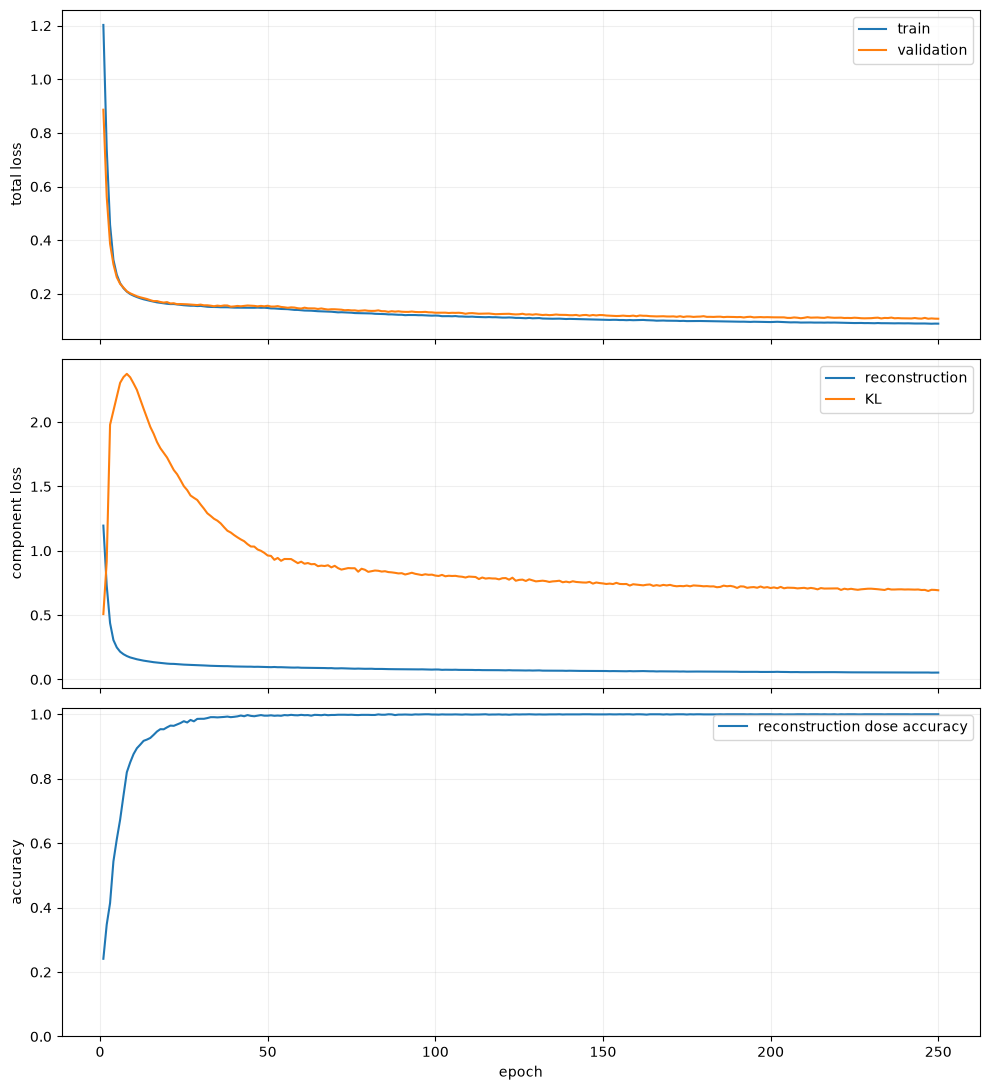

In [7]:
epochs = np.arange(1, len(history["training_loss"]) + 1)
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
axes[0].plot(epochs, history["training_loss"], label="train")
axes[0].plot(epochs, history["validation_loss"], label="validation")
axes[1].plot(epochs, history["reconstruction_loss"], label="reconstruction")
axes[1].plot(epochs, history["kl_loss"], label="KL")
axes[2].plot(epochs, history["dose_accuracy"], label="reconstruction dose accuracy")
axes[0].set_ylabel("total loss"); axes[1].set_ylabel("component loss")
axes[2].set(ylabel="accuracy", xlabel="epoch", ylim=(0, 1.02))
for axis in axes: axis.grid(alpha=0.2); axis.legend()
fig.tight_layout()

### Reconstruction and latent organization on validation data

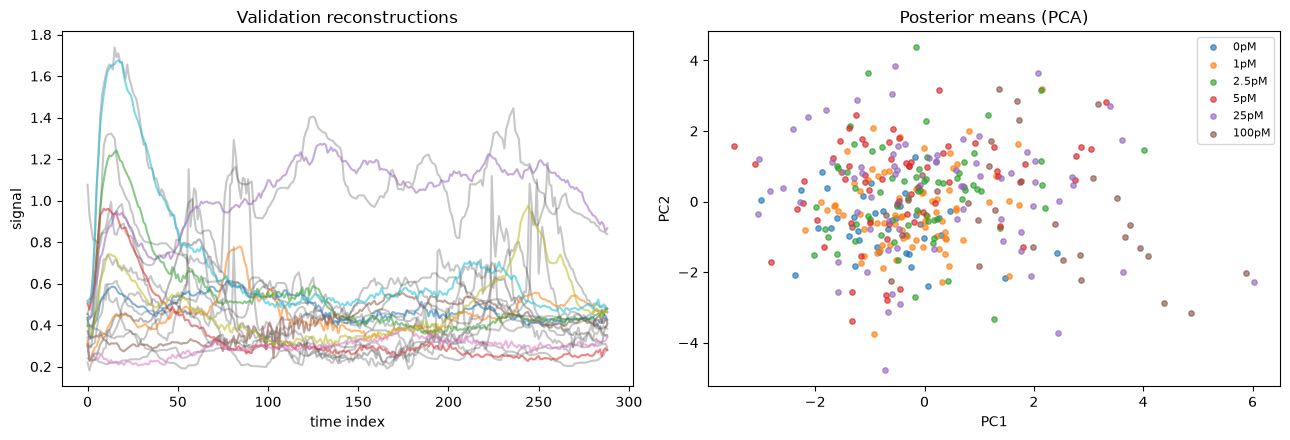

In [15]:
validation_tensor = torch.as_tensor(validation_normalized[:, None, :], dtype=torch.float32, device=device)
validation_target = torch.as_tensor(validation_labels, dtype=torch.long, device=device)
with torch.no_grad():
    posterior_mean, _ = vae.encode(validation_tensor, validation_target)
    reconstructions = vae.decode(posterior_mean, validation_target).squeeze(1).cpu().numpy()
reconstructions = reconstructions * signal_std + signal_mean

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
choice = np.random.default_rng(RANDOM_SEED).choice(len(validation_trajectories), 10, replace=False)
axes[0].plot(validation_trajectories[choice].T, color="black", alpha=0.22)
axes[0].plot(reconstructions[choice].T, alpha=0.55)
axes[0].set(title="Validation reconstructions", xlabel="time index", ylabel="signal")
projection = PCA(n_components=2).fit_transform(posterior_mean.cpu().numpy())
for dose_id, dose in enumerate(dose_names):
    selected = validation_labels == dose_id
    axes[1].scatter(projection[selected, 0], projection[selected, 1], s=15, alpha=0.65, label=dose)
axes[1].set(title="Posterior means (PCA)", xlabel="PC1", ylabel="PC2")
axes[1].legend(fontsize=8)
fig.tight_layout()

## 5. Open test data and draw prior samples

Sampling uses `z ~ N(0, I)` rather than encoded test trajectories. Every dose receives exactly the number of samples present in the test fold.

In [9]:
test_trajectories, test_doses, _ = load_data("test")
test_labels = np.asarray([dose_to_id[str(dose)] for dose in test_doses], dtype=np.int64)
test_counts = np.bincount(test_labels, minlength=len(dose_names))
random = torch.Generator(device=device).manual_seed(RANDOM_SEED + 1)
generated_batches, generated_labels = [], []
with torch.no_grad():
    for dose_id, count in enumerate(test_counts):
        labels = torch.full((int(count),), dose_id, dtype=torch.long, device=device)
        normalized_samples = vae.sample(labels, generator=random).squeeze(1).cpu().numpy()
        generated_batches.append(normalized_samples * signal_std + signal_mean)
        generated_labels.append(np.full(int(count), dose_id))
generated = np.concatenate(generated_batches)
generated_labels = np.concatenate(generated_labels).astype(int)
display(Markdown(f"**Generated test-matched sample:** `{generated.shape}`."))

(349, 289)


In [10]:
FEATURES = ("mean signal", "temporal std", "maximum signal", "dynamic range", "endpoint change", "mean absolute step")

def trajectory_features(values, labels):
    frame = pd.DataFrame({"dose_id": labels})
    frame["mean signal"] = values.mean(1)
    frame["temporal std"] = values.std(1)
    frame["maximum signal"] = values.max(1)
    frame["dynamic range"] = np.ptp(values, axis=1)
    frame["endpoint change"] = values[:, -12:].mean(1) - values[:, :12].mean(1)
    frame["mean absolute step"] = np.abs(np.diff(values, axis=1)).mean(1)
    return frame

real_features = trajectory_features(test_trajectories, test_labels)
vae_features = trajectory_features(generated, generated_labels)

## 6. Held-out feature comparison

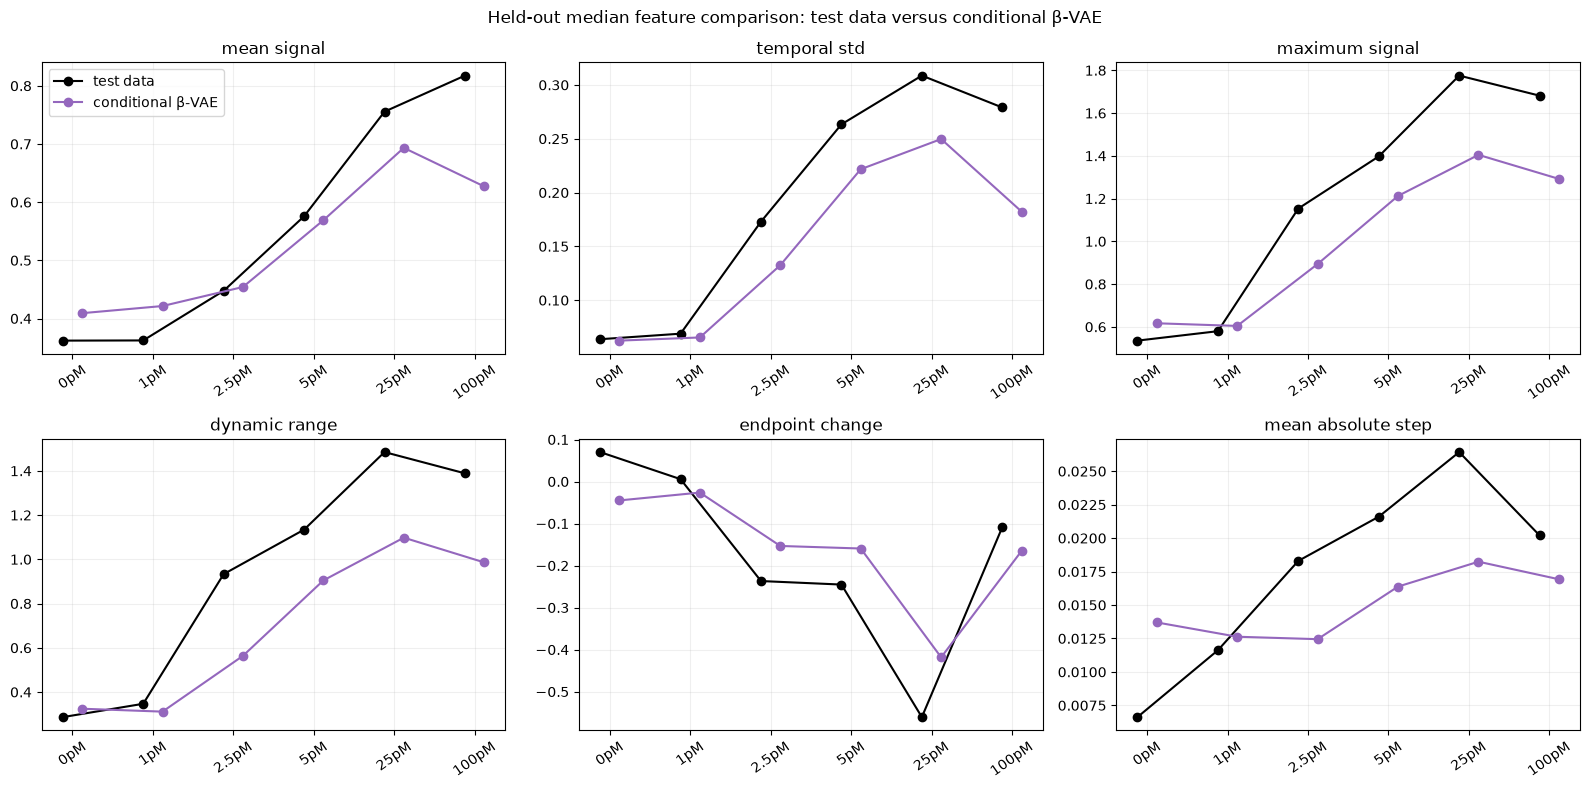

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
positions = np.arange(len(dose_names))
for feature, axis in zip(FEATURES, axes.flat):
    for offset, frame, color, name in ((-0.12, real_features, "black", "test data"), (0.12, vae_features, "tab:purple", "conditional β-VAE")):
        medians = frame.groupby("dose_id")[feature].median().reindex(range(len(dose_names)))
        axis.plot(positions + offset, medians, "o-", color=color, label=name)
    axis.set_title(feature); axis.set_xticks(positions, dose_names, rotation=35); axis.grid(alpha=0.2)
axes[0, 0].legend()
fig.suptitle("Held-out median feature comparison: test data versus conditional β-VAE")
fig.tight_layout()

In [12]:
def feature_nmae(feature):
    real = real_features.groupby("dose_id")[feature].median().reindex(range(len(dose_names))).to_numpy()
    fake = vae_features.groupby("dose_id")[feature].median().reindex(range(len(dose_names))).to_numpy()
    return np.mean(np.abs(real - fake)) / max(float(np.ptp(real)), np.finfo(float).eps)

generated_normalized = torch.as_tensor(((generated - signal_mean) / signal_std)[:, None, :], dtype=torch.float32, device=device)
with torch.no_grad():
    predicted = torch.cat([dose_classifier(batch).argmax(1).cpu() for batch in generated_normalized.split(256)]).numpy()
summary = pd.Series({feature: feature_nmae(feature) for feature in FEATURES}, name="feature NMAE")
summary.loc["mean feature NMAE"] = summary.mean()
summary.loc["dose fidelity"] = np.mean(predicted == generated_labels)
summary.to_frame().round(3)

,feature NMAE
mean signal,0.136
temporal std,0.165
maximum signal,0.176
dynamic range,0.203
endpoint change,0.136
mean absolute step,0.258
mean feature NMAE,0.179
dose fidelity,0.977


## 7. Dose-specific trajectory inspection

Doses are rows. Real test trajectories and VAE prior samples are shown in separate columns so oversmoothing and diversity loss remain visible.

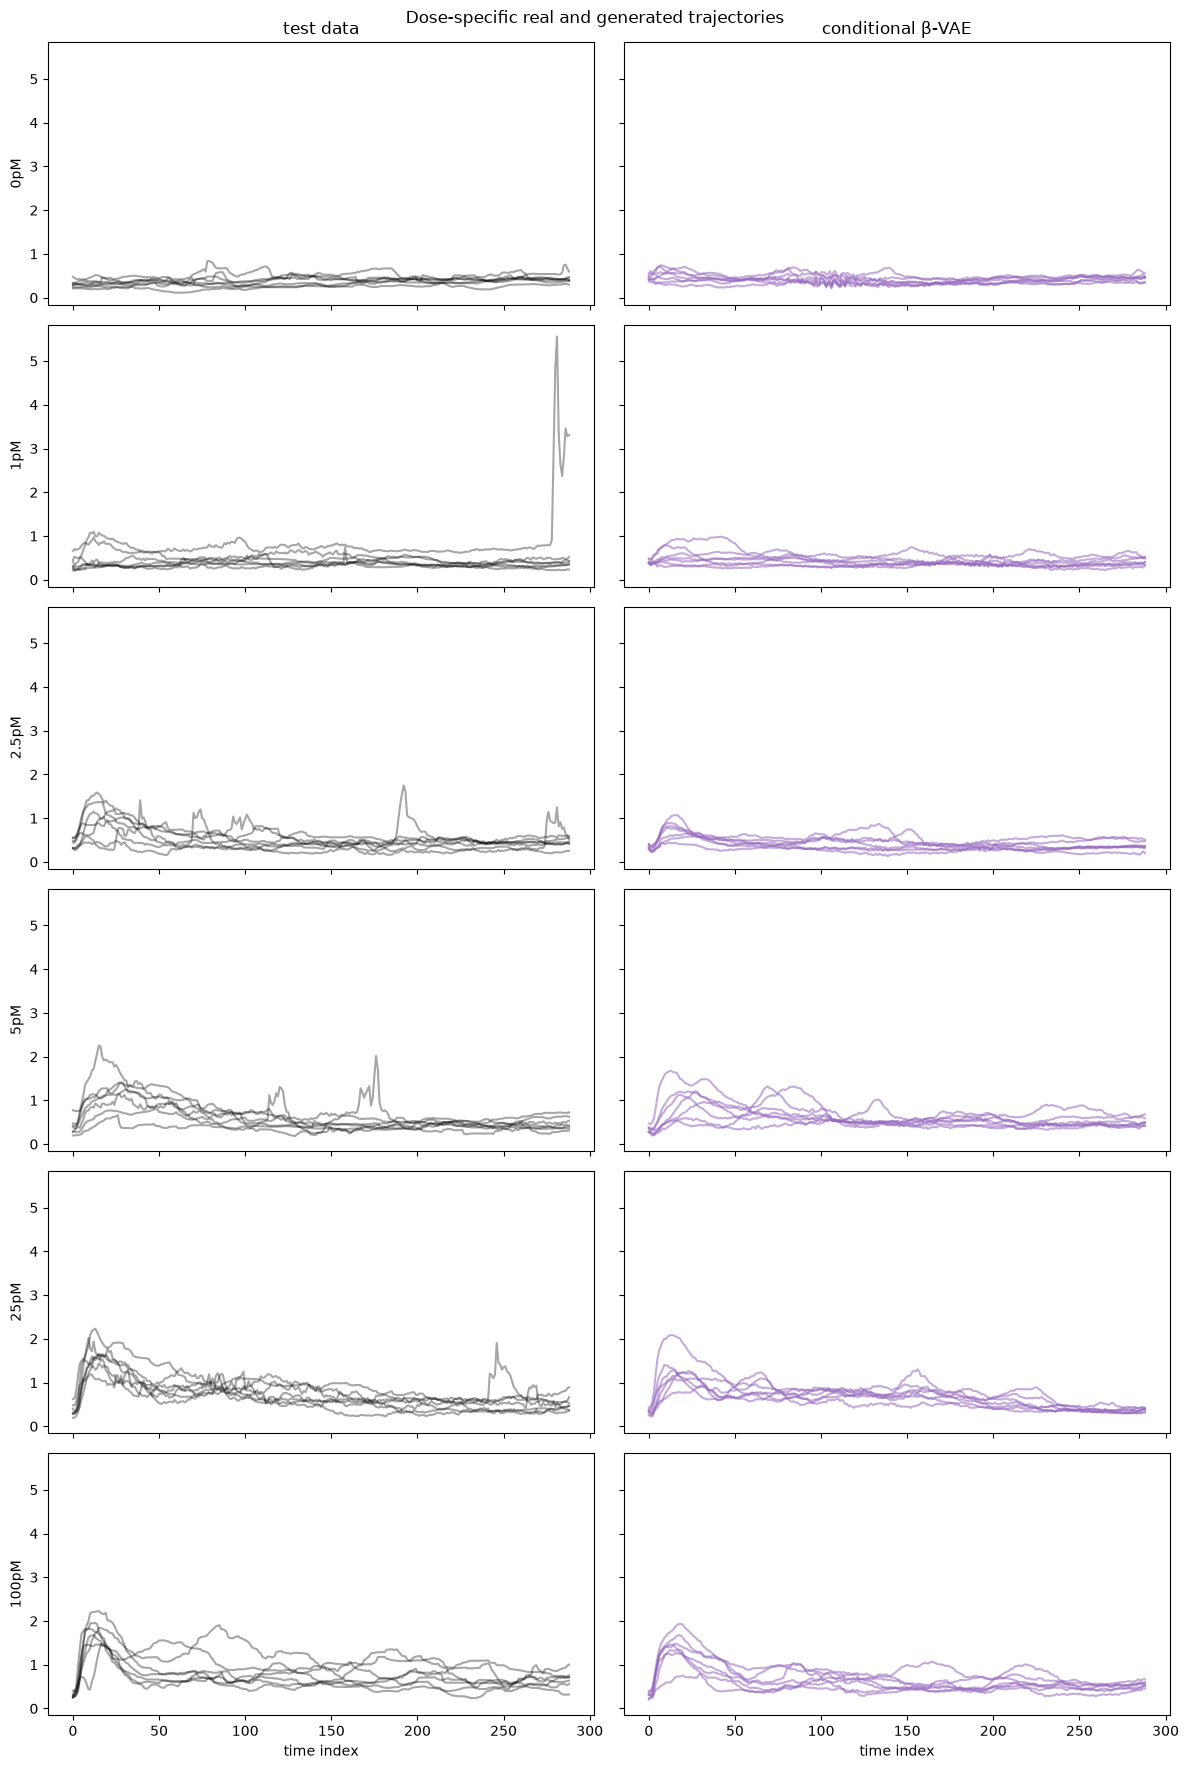

In [13]:
fig, axes = plt.subplots(len(dose_names), 2, figsize=(12, 18), sharex=True, sharey=True)
rng = np.random.default_rng(RANDOM_SEED + 2)
for dose_id, dose in enumerate(dose_names):
    real = test_trajectories[test_labels == dose_id]
    fake = generated[generated_labels == dose_id]
    axes[dose_id, 0].plot(real[rng.choice(len(real), min(7, len(real)), replace=False)].T, color="black", alpha=0.35)
    axes[dose_id, 1].plot(fake[rng.choice(len(fake), min(7, len(fake)), replace=False)].T, color="tab:purple", alpha=0.55)
    axes[dose_id, 0].set_ylabel(str(dose))
axes[0, 0].set_title("test data"); axes[0, 1].set_title("conditional β-VAE")
axes[-1, 0].set_xlabel("time index"); axes[-1, 1].set_xlabel("time index")
fig.suptitle("Dose-specific real and generated trajectories")
fig.tight_layout()

## Result-specific interpretation

In [14]:
feature_errors = summary.loc[list(FEATURES)]
worst_feature = feature_errors.idxmax()
final_kl = history["kl_loss"][-1]
best_validation_epoch = int(np.argmin(history["validation_loss"])) + 1
collapse_statement = (
    "The KL term is below 1e-3, which is concrete evidence of posterior collapse."
    if final_kl < 1e-3
    else "The KL term remains above 1e-3, so this run does not meet the notebook's collapse flag."
)
display(Markdown(
    f"The best validation loss is **{min(history['validation_loss']):.4f} at epoch {best_validation_epoch}**; "
    f"the final recorded KL term is **{final_kl:.4f}**. {collapse_statement}\n\n"
    f"Prior samples achieve **{summary.loc['dose fidelity']:.3f} dose fidelity** and "
    f"**{summary.loc['mean feature NMAE']:.3f} mean feature NMAE**. The largest normalized "
    f"feature error is **{worst_feature} ({feature_errors.loc[worst_feature]:.3f})**. "
    f"This is the first reconstruction/decoder property to target in the next ablation."
))

Best validation loss occurs at epoch 247 (0.1071); final recorded KL=0.6931. The KL term remains above 1e-3, so this run does not meet the notebook's collapse flag.
Prior samples achieve dose fidelity 0.977 and mean feature NMAE 0.179. The largest normalized feature error is mean absolute step (0.258). This identifies the first reconstruction/decoder property to target in the next ablation.


## Next experiments

Candidate extensions are a learned heteroscedastic output likelihood, derivative-aware reconstruction loss, a TCN encoder/decoder and a conditional prior `p(z | dose)`. A VAE-GAN can retain the latent objective while replacing part of the point-wise reconstruction term with critic feature matching. Select among these using the worst feature printed above rather than applying all changes at once.